**Table of contents**<a id='toc0_'></a>

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

In [1]:
from collections import namedtuple

import numpy as np
import numba as nb
import matplotlib.pyplot as plt

from consav.grids import equilogspace
from consav.markov import log_rouwenhorst
from consav.linear_interp import interp_1d_vec

# Exercise: EGM with endogenous labor supply

Households have so far supplied labor inelastically.
Let them choose hours $n_t$, at a utility cost.
Working more is then a second way to self-insure, next to saving, and the exercise is to see what that does to the EGM step, to the policy functions and to the distribution.

$$
\begin{aligned}
v(z_t,a_{t-1}) &= \max_{c_t,n_t} \frac{c_t^{1-\sigma}}{1-\sigma} - \varphi\frac{n_t^{1+\nu}}{1+\nu} + \beta \mathbb{E}_t\left[v(z_{t+1},a_t)\right] \\
&\text{s.t.} \\
a_t &= (1+r)a_{t-1} + wz_tn_t - c_t \geq 0
\end{aligned}
$$

with the same income process as before.
$1/\nu$ is the Frisch elasticity of labor supply.
We set $\nu = 1$ and $\varphi = 1$, so that a household with $z_t = 1$ and $c_t = 1$ works $n_t = 1$.

The simulation part of the household block does not change at all: the histogram only needs $a^{\ast}$.
The whole exercise is in the backward step.

In [2]:
Parameters = namedtuple('Parameters',
    'beta sigma varphi nu r w rho_z sigma_psi Nz Na a_min a_max a_grid z_grid z_trans z_ergodic')

def setup():
    """ baseline parameters """

    # preferences
    beta = 0.96
    sigma = 2.0
    varphi = 1.0
    nu = 1.0

    # prices
    r = 0.02
    w = 1.0

    # income
    rho_z = 0.95
    sigma_psi = 0.10
    Nz = 7
    z_grid,z_trans,z_ergodic,_,_ = log_rouwenhorst(rho_z,sigma_psi,Nz)

    # grids
    Na = 300
    a_min = 0.0
    a_max = 100.0
    a_grid = equilogspace(a_min,a_max,Na)

    return Parameters(beta,sigma,varphi,nu,r,w,rho_z,sigma_psi,Nz,Na,a_min,a_max,a_grid,z_grid,z_trans,z_ergodic)

par = setup()

## Question 1: first-order conditions

Write the Lagrangian with multiplier $\mu_t$ on $a_t \geq 0$ and derive the first-order conditions for $c_t$ and $n_t$, and the envelope condition.
Show that:

1. The Euler-equation is the one we had, $c_t^{-\sigma} = \beta\,\underline{v}_a(z_t,a_t) + \mu_t$, and the envelope condition too, $v_a(z_t,a_{t-1}) = (1+r)c_t^{-\sigma}$.
2. Labor supply is pinned down by consumption alone, through the *intratemporal* condition

$$
\varphi n_t^{\nu} = wz_t\,c_t^{-\sigma}
\quad\Leftrightarrow\quad
n_t = \left(\frac{wz_t}{\varphi}\right)^{1/\nu} c_t^{-\sigma/\nu}
$$

which holds whether or not the borrowing constraint binds.

Why does this make EGM easy to extend?

## Question 2: the EGM step, unconstrained households

Complete the solve step of `solve_hh_backwards`.
On the endogenous grid nothing is new: the Euler-equation gives $c(z_t,a_t)$, the intratemporal condition gives $n(z_t,a_t)$, and the budget constraint gives $a_{t-1}(z_t,a_t)$.
Interpolate both $a^{\ast}$ and $n^{\ast}$ back on the fixed grid.

## Question 3: the EGM step, constrained households

Where the interpolated $a^{\ast}$ is negative, the constraint binds: $a^{\ast} = 0$.
With exogenous labor, consumption then followed from the budget constraint.
Here consumption and hours have to be found *together*: the budget constraint $c = (1+r)a_{t-1} + wz_tn$ and the intratemporal condition are two equations in $(c,n)$.
Substitute one into the other to get a single equation in $n$,

$$
f(n) \equiv n - \left(\frac{wz_t}{\varphi}\right)^{1/\nu}\left[(1+r)a_{t-1} + wz_tn\right]^{-\sigma/\nu} = 0
$$

and solve it with Newton's method, $n \leftarrow n - f(n)/f'(n)$, starting from the interpolated $n^{\ast}$.
Write $f'(n)$ by hand.
Stop when $|f(n)| < 10^{-10}$.

In [3]:
@nb.njit(parallel=True)
def solve_hh_backwards(par,z_trans,r,w,vbeg_a_plus,vbeg_a,a,c,n):
    """ solve backwards with vbeg_a from previous iteration (here vbeg_a_plus) """

    # a. solve step
    for i_z in nb.prange(par.Nz):

        z = par.z_grid[i_z]
        fac = (w*z/par.varphi)**(1/par.nu)

        # i. back out consumption and hours from the two first-order conditions

        # ii. endogenous grid of assets from the budget constraint

        # iii. interpolate a and n to the fixed grid

        # iv. constrained households: a = 0, then Newton on the intratemporal condition for n
        for i_a in range(par.Na):
            pass

        # v. back out consumption

    # b. expectation step
    pass

## Question 4: solve and look at the policy functions

`solve_hh_ss` is given.
Solve, then plot consumption and hours against assets for the lowest, middle and highest productivity state.
Does labor supply fall with wealth? With productivity? Explain both from the intratemporal condition.

In [4]:
def solve_hh_ss(par,r,w,max_iter=10_000,tol=1e-10):
    """ solve the household problem in the infinite horizon """

    # a. allocate
    vbeg_a = np.zeros((par.Nz,par.Na))
    a = np.zeros((par.Nz,par.Na))
    c = np.zeros((par.Nz,par.Na))
    n = np.zeros((par.Nz,par.Na))

    # b. initial guess: a(z,a_) = a_ and n = 1, so consumption is the annuity value
    c_guess = r*par.a_grid[np.newaxis,:] + w*par.z_grid[:,np.newaxis]
    vbeg_a_plus = par.z_trans@((1+r)*c_guess**(-par.sigma))

    # c. iterate
    for it in range(max_iter):

        solve_hh_backwards(par,par.z_trans,r,w,vbeg_a_plus,vbeg_a,a,c,n)

        if np.max(np.abs(vbeg_a-vbeg_a_plus)) < tol: break
        vbeg_a_plus[:] = vbeg_a

    return c,a,n,vbeg_a

In [5]:
# solve and plot the policy functions


## Question 5: simulate and aggregate

The forward step is unchanged, so `simulate_hh_forwards` and `simulate_hh_ss` are given, copied from notebook 05. Build the lottery as there.

1. Find the stationary distribution and compute $A^{hh}$, $C^{hh}$ and aggregate effective labor $L^{hh} = \sum \boldsymbol{D}\, z\, n^{\ast}$.
2. Check the aggregate budget identity, $C^{hh} = rA^{hh} + wL^{hh}$.
3. What share of households is at the borrowing constraint? In notebook 05 it was a quarter. Why would hours choice change that?

In [6]:
@nb.njit
def simulate_hh_forwards(par,Dbeg,pol_indices,pol_weights,Dbeg_plus):
    """ one period forward: productivity transition, then the savings lottery """

    # a. productivity transition
    D = par.z_trans.T@Dbeg

    # b. savings lottery
    Dbeg_plus[:] = 0.0
    for i_z in range(par.Nz):
        for i_a in range(par.Na):

            i = pol_indices[i_z,i_a]
            omega = pol_weights[i_z,i_a]
            Dbeg_plus[i_z,i] += omega*D[i_z,i_a]
            Dbeg_plus[i_z,i+1] += (1-omega)*D[i_z,i_a]

    return D

def simulate_hh_ss(par,pol_indices,pol_weights,max_iter=100_000,tol=1e-13):
    """ iterate the forward step until the distribution stops moving """

    Dbeg = np.zeros((par.Nz,par.Na))
    Dbeg[:,0] = par.z_ergodic
    Dbeg_plus = np.zeros_like(Dbeg)

    for it in range(max_iter):

        D = simulate_hh_forwards(par,Dbeg,pol_indices,pol_weights,Dbeg_plus)

        if np.max(np.abs(Dbeg_plus-Dbeg)) < tol: break
        Dbeg,Dbeg_plus = Dbeg_plus,Dbeg

    return Dbeg_plus,D,it

In [7]:
# lottery, stationary distribution, aggregates, budget check, share at the constraint


## Answers

### Question 1

$$
\mathcal{L} = \frac{c_t^{1-\sigma}}{1-\sigma} - \varphi\frac{n_t^{1+\nu}}{1+\nu} + \beta\,\underline{v}(z_t,a_t) + \mu_t a_t,
\qquad a_t = (1+r)a_{t-1} + wz_tn_t - c_t
$$

- $c_t$: $c_t^{-\sigma} = \beta\,\underline{v}_a(z_t,a_t) + \mu_t$
- $n_t$: $\varphi n_t^{\nu} = wz_t\left[\beta\,\underline{v}_a(z_t,a_t) + \mu_t\right] = wz_t c_t^{-\sigma}$
- envelope: $v_a(z_t,a_{t-1}) = (1+r)\left[\beta\,\underline{v}_a(z_t,a_t) + \mu_t\right] = (1+r)c_t^{-\sigma}$

The multiplier drops out of the labor condition because $c_t$ and $n_t$ face the same shadow price of assets.
So the trade-off between consumption and leisure is *static*, and the constraint only enters through $c_t$.

This is what makes EGM easy to extend: the Euler-equation still gives $c$ on the endogenous grid, and $n$ is a closed-form function of that $c$.
The only place where more work is needed is the constrained region, because there $c$ is no longer given by the Euler-equation but by the budget constraint, which contains $n$.

### Questions 2 and 3

In [8]:
@nb.njit(parallel=True)
def solve_hh_backwards(par,z_trans,r,w,vbeg_a_plus,vbeg_a,a,c,n):
    """ solve backwards with vbeg_a from previous iteration (here vbeg_a_plus) """

    # a. solve step
    for i_z in nb.prange(par.Nz):

        z = par.z_grid[i_z]
        fac = (w*z/par.varphi)**(1/par.nu)

        # i. back out consumption and hours from the two first-order conditions
        c_endo = (par.beta*vbeg_a_plus[i_z])**(-1/par.sigma)
        n_endo = fac*c_endo**(-par.sigma/par.nu)

        # ii. endogenous grid of assets from the budget constraint
        a_endo = (c_endo + par.a_grid - w*z*n_endo)/(1+r)

        # iii. interpolate a and n to the fixed grid
        interp_1d_vec(a_endo,par.a_grid,par.a_grid,a[i_z])
        interp_1d_vec(a_endo,n_endo,par.a_grid,n[i_z])

        # iv. constrained households: a = 0, then Newton on the intratemporal condition for n
        for i_a in range(par.Na):

            if a[i_z,i_a] >= 0.0: break # a is increasing in a_, so the constrained region ends here

            a[i_z,i_a] = 0.0

            n_i = n[i_z,i_a]
            for it in range(100):

                c_i = (1+r)*par.a_grid[i_a] + w*z*n_i
                f = n_i - fac*c_i**(-par.sigma/par.nu)
                if np.abs(f) < 1e-10: break

                df = 1 + fac*(par.sigma/par.nu)*c_i**(-par.sigma/par.nu-1)*w*z
                n_i = n_i - f/df

            n[i_z,i_a] = n_i

        # v. back out consumption
        c[i_z] = par.a_grid*(1+r) + w*z*n[i_z] - a[i_z]

    # b. expectation step
    v_a = (1+r)*c**(-par.sigma)
    vbeg_a[:] = z_trans@v_a

Two details.
The constrained region is an interval at the bottom of the asset grid, since $a^{\ast}$ is increasing in $a_{t-1}$, so the loop can stop at the first unconstrained point.
And Newton converges in a handful of steps here because $f$ is increasing and convex in $n$ and the interpolated $n^{\ast}$ is already close.

### Question 4

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


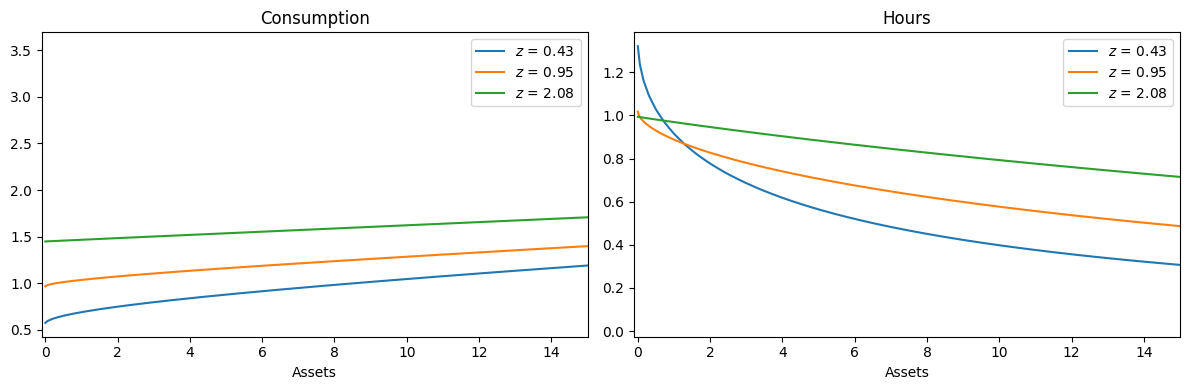

In [9]:
c,a,n,vbeg_a = solve_hh_ss(par,par.r,par.w)

fig,ax = plt.subplots(1,2,figsize=(12,4))
for i_z in [0,par.Nz//2,par.Nz-1]:
    ax[0].plot(par.a_grid,c[i_z],label=f'$z$ = {par.z_grid[i_z]:.2f}')
    ax[1].plot(par.a_grid,n[i_z],label=f'$z$ = {par.z_grid[i_z]:.2f}')
for ax_ in ax:
    ax_.set_xlim(-0.1,15)
    ax_.set_xlabel('Assets')
    ax_.legend()
ax[0].set_title('Consumption')
ax[1].set_title('Hours')
fig.tight_layout()
fig.savefig('figs/labor_policy.pdf')
plt.show()

Hours fall with wealth: from $\varphi n^{\nu} = wzc^{-\sigma}$, richer households consume more, so the marginal utility of consumption is lower and an extra hour buys less utility.
This is the wealth effect on labor supply, and it is what a poor household uses to self-insure: hit by a bad shock, it cuts consumption *and* works more.

Across productivity states the effect is ambiguous in general: a higher $z$ raises the return to an hour (substitution effect) but also raises consumption (wealth effect).
With $\sigma = 2$ and $\nu = 1$ the wealth effect wins at low wealth, where the low-$z$ households work the most, and the substitution effect wins from about one year of income on, where the ranking flips.

### Question 5

In [10]:
# a. find the left neighbor of a*(z,a_) on the asset grid
pol_indices = np.zeros((par.Nz,par.Na),dtype=np.int64)
pol_weights = np.zeros((par.Nz,par.Na))

for i_z in range(par.Nz):

    i = np.searchsorted(par.a_grid,a[i_z],side='right') - 1
    i = np.clip(i,0,par.Na-2)

    # b. share omega to i, 1-omega to i+1
    pol_indices[i_z] = i
    pol_weights[i_z] = (par.a_grid[i+1]-a[i_z])/(par.a_grid[i+1]-par.a_grid[i])

assert np.all((pol_weights >= 0.0) & (pol_weights <= 1.0))

# c. stationary distribution
Dbeg_ss,D_ss,it = simulate_hh_ss(par,pol_indices,pol_weights)
print(f'converged in {it} iterations')

# d. aggregates
A_hh = np.sum(D_ss*a)
C_hh = np.sum(D_ss*c)
L_hh = np.sum(D_ss*par.z_grid[:,np.newaxis]*n)

print(f'A_hh = {A_hh:.4f}')
print(f'C_hh = {C_hh:.4f}')
print(f'L_hh = {L_hh:.4f}')
print(f'C_hh - (r*A_hh + w*L_hh) = {C_hh-(par.r*A_hh+par.w*L_hh):.2e}')
print(f'share at the constraint: {np.sum(D_ss[a == 0.0]):.3f}')

converged in 323 iterations
A_hh = 0.5520
C_hh = 0.9934
L_hh = 0.9824
C_hh - (r*A_hh + w*L_hh) = -8.87e-13
share at the constraint: 0.540


More than half of all households sit at the constraint, twice the share of notebook 05, and aggregate assets are about half.

Hours are a second margin of adjustment.
A household with no assets can absorb a bad income shock by working more instead of cutting consumption, so the buffer is worth less to it, and many households choose to hold none.
Self-insurance through labor crowds out self-insurance through saving.

This is also why HANK models care about the labor supply specification: whether households can adjust hours changes how much consumption responds to a shock, and hence the aggregate MPC.